# Challenge 2 — Hacia el agua limpia para todos
## Parte 1 V3: SVM-RBF, ingeniería de características y benchmark clásico de 64 muestras

Esta versión parte de la ejecución real de V2 y mantiene el mismo holdout de referencia. Sus objetivos son:

1. comparar ingeniería fisicoquímica, winsorización, geometría local y métodos de limpieza sin fuga de información;
2. seleccionar la configuración por validación cruzada, dando prioridad a **F1 sujeto a una especificidad mínima**;
3. comparar contra la configuración ganadora de V2;
4. crear una rama clásica independiente entrenada con **64 muestras reales del pool de entrenamiento** —32 por clase— para preparar una comparación futura con QSVM;
5. no ejecutar todavía QSVM ni la selección determinista avanzada de las 64 muestras.

> El holdout de V2 ya fue observado. En V3 se conserva para comparar versiones, pero debe interpretarse como un **benchmark de regresión**, no como una estimación final completamente ciega.


## 0. Principios metodológicos

- El split se realiza antes de aprender imputación, límites de winsorización, escalado, clusters, densidad, limpieza o sobremuestreo.
- Todas las transformaciones se ajustan dentro de cada fold mediante `imblearn.Pipeline`.
- Los puntos conflictivos no se borran globalmente. Se comparan métodos como Tomek, ENN, AllKNN, NCR, SMOTE-Tomek y SMOTE-ENN únicamente en entrenamiento.
- Optuna optimiza capacidad de ranking —average precision y ROC-AUC—, no el test.
- La decisión operacional se ajusta posteriormente con predicciones out-of-fold.
- La política principal de V3 maximiza F1 bajo una restricción mínima de especificidad.
- La rama de 64 muestras no utiliza el holdout para escoger observaciones ni hiperparámetros.


## 1. Instalación e importaciones


In [1]:
from google.colab import drive
drive.mount('/content/drive/')


Mounted at /content/drive/


In [2]:
%pip install -q -U imbalanced-learn optuna kagglehub joblib cloudpickle


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 14.5 MB/s eta 0:00:00


In [3]:
from __future__ import annotations

import json
import math
import platform
import sys
import warnings
from collections import Counter
from pathlib import Path
from typing import Any

import cloudpickle
import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import sklearn
import imblearn

from IPython.display import display
from optuna.samplers import TPESampler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import MiniBatchKMeans
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import PowerTransformer, RobustScaler, StandardScaler
from sklearn.svm import SVC

from imblearn import FunctionSampler
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import (
    AllKNN,
    EditedNearestNeighbours,
    NeighbourhoodCleaningRule,
    TomekLinks,
)

warnings.filterwarnings('ignore')

print('Python:', sys.version.split()[0])
print('scikit-learn:', sklearn.__version__)
print('imbalanced-learn:', imblearn.__version__)
print('Optuna:', optuna.__version__)


Python: 3.12.13
scikit-learn: 1.6.1
imbalanced-learn: 0.14.2
Optuna: 4.9.0


## 2. Configuración reproducible


In [4]:
SEED = 42
AUDIT_TEST_SEED = 20260721
TARGET = 'Potability'
TEST_SIZE = 0.20
N_SPLITS = 5
N_JOBS = -1

FEATURES = [
    'ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
    'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity',
]

BASE_DIR = Path('/content/drive/MyDrive/Colab Notebooks')
V2_ARTIFACT_DIR = BASE_DIR / 'artifacts_v2'
ARTIFACT_DIR = BASE_DIR / 'artifacts_v3'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# quick: verificación | balanced: recomendado | full: búsqueda extensa
EXPERIMENT_MODE = 'balanced'
MODE_CONFIG = {
    'quick': {
        'n_trials': 18,
        'search_repeats': 1,
        'top_k': 4,
        'stability_repeats': 2,
        'small64_trials': 18,
        'small64_repeats': 4,
    },
    'balanced': {
        'n_trials': 60,
        'search_repeats': 2,
        'top_k': 8,
        'stability_repeats': 4,
        'small64_trials': 45,
        'small64_repeats': 10,
    },
    'full': {
        'n_trials': 120,
        'search_repeats': 4,
        'top_k': 12,
        'stability_repeats': 6,
        'small64_trials': 80,
        'small64_repeats': 20,
    },
}
CFG = MODE_CONFIG[EXPERIMENT_MODE]

MIN_SAFETY_SPECIFICITY = 0.75
OBJECTIVE_STD_PENALTY = 0.10
SIMPLICITY_TOLERANCE = 0.005

SMALL64_SEED = 6403
SMALL64_CV_SEED = 6411
SMALL64_N_PER_CLASS = 32
SMALL64_FOLDS = 4

print(json.dumps({'mode': EXPERIMENT_MODE, **CFG}, indent=2))


{
  "mode": "balanced",
  "n_trials": 60,
  "search_repeats": 2,
  "top_k": 8,
  "stability_repeats": 4,
  "small64_trials": 45,
  "small64_repeats": 10
}


## 3. Carga robusta del dataset


In [5]:
def resolve_dataset_path() -> Path:
    candidates = [
        Path('/content/water_potability.csv'),
        Path('/content/drive/MyDrive/water_potability.csv'),
        Path('/content/drive/MyDrive/Colab Notebooks/water_potability.csv'),
        Path('/kaggle/input/water-potability/water_potability.csv'),
        Path('/mnt/data/water_potability.csv'),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate

    try:
        import kagglehub
        dataset_dir = Path(kagglehub.dataset_download('adityakadiwal/water-potability'))
        matches = list(dataset_dir.rglob('water_potability.csv'))
        if matches:
            return matches[0]
    except Exception as exc:
        print('KaggleHub no pudo resolver el archivo:', repr(exc))

    raise FileNotFoundError(
        'No se encontró water_potability.csv. Súbelo a /content o colócalo en Drive.'
    )

DATA_PATH = resolve_dataset_path()
df = pd.read_csv(DATA_PATH)
print('Archivo:', DATA_PATH)
print('Forma:', df.shape)
display(df.head())


100%|██████████| 251k/251k [00:00<00:00, 26.5MB/s]

Extracting files...
Archivo: /root/.cache/kagglehub/datasets/adityakadiwal/water-potability/versions/3/water_potability.csv
Forma: (3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## 4. Auditoría y reconstrucción exacta del split de V2


In [6]:
EXPECTED_COLUMNS = FEATURES + [TARGET]
assert list(df.columns) == EXPECTED_COLUMNS
assert df[TARGET].notna().all()
assert set(df[TARGET].unique()).issubset({0, 1})
assert df.duplicated().sum() == 0

missing_table = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_pct': (100 * df.isna().mean()).round(2),
})
class_table = df[TARGET].value_counts().sort_index().to_frame('count')
class_table['percentage'] = (100 * class_table['count'] / len(df)).round(2)

display(missing_table)
display(class_table)

X = df[FEATURES].copy()
y = df[TARGET].astype(int).copy()

locked_v2_path = V2_ARTIFACT_DIR / 'audit_test_v2_locked.csv'
if locked_v2_path.exists():
    locked_v2 = pd.read_csv(locked_v2_path)
    test_indices = pd.Index(locked_v2['source_index'].astype(int))
    assert len(test_indices) == len(set(test_indices))
    assert set(test_indices).issubset(set(df.index))
    print('Se reutilizan los índices congelados de V2:', locked_v2_path)
else:
    _, test_indices = train_test_split(
        df.index,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=AUDIT_TEST_SEED,
    )
    test_indices = pd.Index(test_indices)
    print('No se encontró el artefacto V2; se reconstruyó el split con la misma semilla.')

train_indices = pd.Index([idx for idx in df.index if idx not in set(test_indices)])
X_train = X.loc[train_indices].copy()
X_test = X.loc[test_indices].copy()
y_train = y.loc[train_indices].copy()
y_test = y.loc[test_indices].copy()

assert set(X_train.index).isdisjoint(X_test.index)
assert len(X_train) + len(X_test) == len(df)

split_summary = pd.DataFrame({
    'split': ['train_v3', 'reference_holdout_v2'],
    'n': [len(y_train), len(y_test)],
    'class_0': [(y_train == 0).sum(), (y_test == 0).sum()],
    'class_1': [(y_train == 1).sum(), (y_test == 1).sum()],
    'positive_pct': [100 * y_train.mean(), 100 * y_test.mean()],
})
display(split_summary.round(2))

locked_test = X_test.copy()
locked_test.insert(0, 'source_index', locked_test.index)
locked_test[TARGET] = y_test
locked_test.to_csv(ARTIFACT_DIR / 'reference_holdout_v2_locked.csv', index=False)


,dtype,missing,missing_pct
ph,float64,491,14.99
Hardness,float64,0,0.00
Solids,float64,0,0.00
Chloramines,float64,0,0.00
Sulfate,float64,781,23.84
Conductivity,float64,0,0.00
Organic_carbon,float64,0,0.00
Trihalomethanes,float64,162,4.95
Turbidity,float64,0,0.00
Potability,int64,0,0.00


,count,percentage
Potability,,
0,1998,60.99
1,1278,39.01


Se reutilizan los índices congelados de V2: /content/drive/MyDrive/Colab Notebooks/artifacts_v2/audit_test_v2_locked.csv


,split,n,class_0,class_1,positive_pct
0,train_v3,2620,1598,1022,39.01
1,reference_holdout_v2,656,400,256,39.02


## 5. Transformadores sin fuga de información

V3 incorpora tres familias nuevas:

1. **Ingeniería fisicoquímica:** desviación del pH, logaritmos, razones e interacciones.
2. **Winsorización:** límites aprendidos dentro de cada fold para reducir influencia extrema sin borrar filas completas.
3. **Geometría local no supervisada:** densidad por vecinos, distancias a clusters y puntaje de anomalía.


In [7]:
class ChemistryFeatureEngineer(BaseEstimator, TransformerMixin):
    """Añade un conjunto pequeño y controlado de características derivadas."""

    def __init__(self, mode: str = 'none', epsilon: float = 1e-6):
        self.mode = mode
        self.epsilon = epsilon

    def fit(self, X, y=None):
        if hasattr(X, 'columns'):
            self.feature_names_in_ = np.asarray(list(X.columns), dtype=object)
        else:
            self.feature_names_in_ = np.asarray(FEATURES, dtype=object)
        return self

    def _to_frame(self, X) -> pd.DataFrame:
        if isinstance(X, pd.DataFrame):
            return X.copy()
        return pd.DataFrame(np.asarray(X), columns=self.feature_names_in_)

    @staticmethod
    def _positive_log(series: pd.Series) -> pd.Series:
        values = pd.to_numeric(series, errors='coerce')
        return np.log1p(values.clip(lower=0))

    def _safe_ratio(self, numerator: pd.Series, denominator: pd.Series) -> pd.Series:
        den = denominator.astype(float).copy()
        den = den.where(np.abs(den) > self.epsilon, np.nan)
        return numerator.astype(float) / den

    def transform(self, X):
        frame = self._to_frame(X)
        if self.mode == 'none':
            return frame

        if self.mode in {'basic', 'full'}:
            frame['ph_deviation_from_7'] = (frame['ph'] - 7.0).abs()
            frame['log_solids'] = self._positive_log(frame['Solids'])
            frame['log_conductivity'] = self._positive_log(frame['Conductivity'])
            frame['log_trihalomethanes'] = self._positive_log(frame['Trihalomethanes'])

        if self.mode in {'ratios', 'full'}:
            frame['conductivity_per_solids'] = self._safe_ratio(
                frame['Conductivity'], frame['Solids']
            )
            frame['hardness_per_solids'] = self._safe_ratio(
                frame['Hardness'], frame['Solids']
            )
            frame['sulfate_per_hardness'] = self._safe_ratio(
                frame['Sulfate'], frame['Hardness']
            )
            frame['chloramines_per_organic_carbon'] = self._safe_ratio(
                frame['Chloramines'], frame['Organic_carbon']
            )
            frame['trihalomethanes_per_organic_carbon'] = self._safe_ratio(
                frame['Trihalomethanes'], frame['Organic_carbon']
            )

        if self.mode == 'full':
            frame['mineral_interaction'] = frame['Hardness'] * frame['Sulfate']
            frame['disinfection_interaction'] = (
                frame['Chloramines'] * frame['Organic_carbon']
            )
            frame['thm_chloramine_ratio'] = self._safe_ratio(
                frame['Trihalomethanes'], frame['Chloramines']
            )

        # Cualquier división extremadamente inestable se trata como faltante y
        # será imputada dentro del fold, nunca con información externa.
        frame = frame.replace([np.inf, -np.inf], np.nan)
        return frame

    def get_feature_names_out(self, input_features=None):
        base = list(input_features if input_features is not None else self.feature_names_in_)
        extra = []
        if self.mode in {'basic', 'full'}:
            extra += [
                'ph_deviation_from_7', 'log_solids',
                'log_conductivity', 'log_trihalomethanes',
            ]
        if self.mode in {'ratios', 'full'}:
            extra += [
                'conductivity_per_solids', 'hardness_per_solids',
                'sulfate_per_hardness', 'chloramines_per_organic_carbon',
                'trihalomethanes_per_organic_carbon',
            ]
        if self.mode == 'full':
            extra += [
                'mineral_interaction', 'disinfection_interaction',
                'thm_chloramine_ratio',
            ]
        return np.asarray(base + extra, dtype=object)


class QuantileClipper(BaseEstimator, TransformerMixin):
    """Winsoriza por columna usando cuantiles aprendidos solo en entrenamiento."""

    def __init__(self, lower: float = 0.01, upper: float = 0.99, enabled: bool = True):
        self.lower = lower
        self.upper = upper
        self.enabled = enabled

    def fit(self, X, y=None):
        arr = np.asarray(X, dtype=float)
        self.n_features_in_ = arr.shape[1]
        if self.enabled:
            self.lower_bounds_ = np.nanquantile(arr, self.lower, axis=0)
            self.upper_bounds_ = np.nanquantile(arr, self.upper, axis=0)
        return self

    def transform(self, X):
        arr = np.asarray(X, dtype=float)
        if not self.enabled:
            return arr
        return np.clip(arr, self.lower_bounds_, self.upper_bounds_)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.asarray([f'x{i}' for i in range(self.n_features_in_)], dtype=object)
        return np.asarray(input_features, dtype=object)


class LocalGeometryFeatures(BaseEstimator, TransformerMixin):
    """Añade señales no supervisadas ajustadas exclusivamente con el fold de entrenamiento."""

    def __init__(
        self,
        mode: str = 'none',
        n_neighbors: int = 7,
        n_clusters: int = 5,
        random_state: int = 42,
    ):
        self.mode = mode
        self.n_neighbors = n_neighbors
        self.n_clusters = n_clusters
        self.random_state = random_state

    def fit(self, X, y=None):
        arr = np.asarray(X, dtype=float)
        self.n_features_in_ = arr.shape[1]
        self._fit_X_ = arr.copy()
        self._uses_density = 'density' in self.mode
        self._uses_clusters = 'clusters' in self.mode
        self._uses_anomaly = 'anomaly' in self.mode

        if self._uses_density:
            k = min(max(2, int(self.n_neighbors) + 1), len(arr))
            self.nn_ = NearestNeighbors(n_neighbors=k)
            self.nn_.fit(arr)

        if self._uses_clusters:
            k_clusters = min(max(2, int(self.n_clusters)), len(arr))
            self.kmeans_ = MiniBatchKMeans(
                n_clusters=k_clusters,
                random_state=self.random_state,
                batch_size=min(256, len(arr)),
                n_init=10,
            )
            self.kmeans_.fit(arr)

        if self._uses_anomaly:
            self.isolation_ = IsolationForest(
                n_estimators=100,
                contamination='auto',
                random_state=self.random_state,
                n_jobs=1,
            )
            self.isolation_.fit(arr)
        return self

    def _append(self, arr, training: bool):
        extras = []
        if self._uses_density:
            if training:
                distances, _ = self.nn_.kneighbors(arr)
                density_distance = distances[:, 1:].mean(axis=1)
            else:
                k = min(int(self.n_neighbors), self.nn_.n_samples_fit_)
                distances, _ = self.nn_.kneighbors(arr, n_neighbors=k)
                density_distance = distances.mean(axis=1)
            extras.append(density_distance[:, None])

        if self._uses_clusters:
            extras.append(self.kmeans_.transform(arr))

        if self._uses_anomaly:
            anomaly_score = -self.isolation_.score_samples(arr)
            extras.append(anomaly_score[:, None])

        if not extras:
            return arr
        return np.column_stack([arr, *extras])

    def fit_transform(self, X, y=None, **fit_params):
        arr = np.asarray(X, dtype=float)
        self.fit(arr, y)
        return self._append(arr, training=True)

    def transform(self, X):
        arr = np.asarray(X, dtype=float)
        same_training_matrix = (
            arr.shape == self._fit_X_.shape
            and np.array_equal(arr, self._fit_X_, equal_nan=True)
        )
        return self._append(arr, training=same_training_matrix)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            names = [f'x{i}' for i in range(self.n_features_in_)]
        else:
            names = list(input_features)
        if self._uses_density:
            names.append('local_mean_neighbor_distance')
        if self._uses_clusters:
            names.extend([f'distance_to_cluster_{i}' for i in range(self.kmeans_.n_clusters)])
        if self._uses_anomaly:
            names.append('isolation_anomaly_score')
        return np.asarray(names, dtype=object)


## 6. Pipeline V3 y espacio de búsqueda


In [8]:
def winsor_parameters(mode: str) -> tuple[bool, float, float]:
    if mode == 'none':
        return False, 0.0, 1.0
    if mode == 'p01':
        return True, 0.01, 0.99
    if mode == 'p025':
        return True, 0.025, 0.975
    raise ValueError(f'Modo de winsorización desconocido: {mode}')


def build_pipeline(params: dict[str, Any], seed: int = SEED) -> Pipeline:
    feature_engineer = ChemistryFeatureEngineer(mode=params['feature_mode'])

    imputer = SimpleImputer(
        strategy='median',
        add_indicator=(params['imputer'] == 'median_indicator'),
    )

    enabled, lower, upper = winsor_parameters(params['winsor_mode'])
    winsorizer = QuantileClipper(lower=lower, upper=upper, enabled=enabled)

    scaler_name = params['scaler']
    if scaler_name == 'standard':
        scaler = StandardScaler()
    elif scaler_name == 'robust':
        scaler = RobustScaler(quantile_range=(10, 90))
    elif scaler_name == 'power':
        scaler = PowerTransformer(method='yeo-johnson', standardize=True)
    else:
        raise ValueError(f'Escalador desconocido: {scaler_name}')

    geometry = LocalGeometryFeatures(
        mode=params['local_geometry'],
        n_neighbors=int(params.get('geometry_neighbors', 7)),
        n_clusters=int(params.get('geometry_clusters', 5)),
        random_state=seed,
    )

    strategy = params['sampling_strategy_name']
    class_weight = None
    cleaning_neighbors = int(params.get('cleaning_neighbors', 3))

    if strategy == 'none':
        sampler = FunctionSampler(validate=False)
    elif strategy == 'class_weight_balanced':
        sampler = FunctionSampler(validate=False)
        class_weight = 'balanced'
    elif strategy == 'tomek':
        sampler = TomekLinks(sampling_strategy='auto')
    elif strategy == 'enn':
        sampler = EditedNearestNeighbours(n_neighbors=cleaning_neighbors)
    elif strategy == 'allknn':
        sampler = AllKNN(n_neighbors=cleaning_neighbors)
    elif strategy == 'ncr':
        sampler = NeighbourhoodCleaningRule(n_neighbors=cleaning_neighbors)
    elif strategy == 'smote':
        sampler = SMOTE(
            sampling_strategy=float(params['smote_ratio']),
            k_neighbors=int(params['smote_neighbors']),
            random_state=seed,
        )
    elif strategy == 'smote_tomek':
        sampler = SMOTETomek(
            smote=SMOTE(
                sampling_strategy=float(params['smote_ratio']),
                k_neighbors=int(params['smote_neighbors']),
                random_state=seed,
            ),
            random_state=seed,
        )
    elif strategy == 'smote_enn':
        sampler = SMOTEENN(
            smote=SMOTE(
                sampling_strategy=float(params['smote_ratio']),
                k_neighbors=int(params['smote_neighbors']),
                random_state=seed,
            ),
            enn=EditedNearestNeighbours(n_neighbors=3),
            random_state=seed,
        )
    else:
        raise ValueError(f'Estrategia desconocida: {strategy}')

    svc = SVC(
        kernel='rbf',
        C=float(params['C']),
        gamma=float(params['gamma']),
        class_weight=class_weight,
        probability=False,
        cache_size=1800,
        random_state=seed,
    )

    return Pipeline([
        ('feature_engineer', feature_engineer),
        ('imputer', imputer),
        ('winsorizer', winsorizer),
        ('scaler', scaler),
        ('local_geometry', geometry),
        ('sampler', sampler),
        ('svc', svc),
    ])


def sample_trial_params(trial: optuna.Trial) -> dict[str, Any]:
    trial.suggest_categorical('feature_mode', ['none', 'basic', 'ratios', 'full'])
    trial.suggest_categorical('imputer', ['median', 'median_indicator'])
    trial.suggest_categorical('winsor_mode', ['none', 'p01', 'p025'])
    trial.suggest_categorical('scaler', ['standard', 'robust', 'power'])

    geometry = trial.suggest_categorical(
        'local_geometry',
        ['none', 'density', 'density_clusters', 'density_anomaly'],
    )
    if 'density' in geometry:
        trial.suggest_int('geometry_neighbors', 5, 15, step=2)
    if 'clusters' in geometry:
        trial.suggest_int('geometry_clusters', 3, 7)

    strategy = trial.suggest_categorical(
        'sampling_strategy_name',
        [
            'none', 'class_weight_balanced', 'tomek', 'enn', 'allknn', 'ncr',
            'smote', 'smote_tomek', 'smote_enn',
        ],
    )
    if strategy in {'enn', 'allknn', 'ncr'}:
        trial.suggest_int('cleaning_neighbors', 3, 7, step=2)
    if strategy in {'smote', 'smote_tomek', 'smote_enn'}:
        trial.suggest_float('smote_ratio', 0.65, 1.0)
        trial.suggest_int('smote_neighbors', 3, 9, step=2)

    trial.suggest_float('C', 1e-2, 1e2, log=True)
    trial.suggest_float('gamma', 1e-3, 1.0, log=True)
    return dict(trial.params)


## 7. Optuna: ranking estable mediante validación cruzada repetida


In [9]:
search_cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=CFG['search_repeats'],
    random_state=SEED,
)
SEARCH_SPLITS = list(search_cv.split(X_train, y_train))
print('Folds por ensayo:', len(SEARCH_SPLITS))


def optuna_objective(trial: optuna.Trial) -> float:
    params = sample_trial_params(trial)
    fold_ap, fold_roc = [], []

    for fold_number, (train_pos, valid_pos) in enumerate(SEARCH_SPLITS):
        model = build_pipeline(params, seed=SEED + trial.number * 100 + fold_number)
        try:
            model.fit(X_train.iloc[train_pos], y_train.iloc[train_pos])
            scores = model.decision_function(X_train.iloc[valid_pos])
            truth = y_train.iloc[valid_pos]
            fold_ap.append(average_precision_score(truth, scores))
            fold_roc.append(roc_auc_score(truth, scores))
        except Exception as exc:
            trial.set_user_attr('failed_fold', fold_number)
            trial.set_user_attr('failure', repr(exc)[:400])
            return 0.0

    mean_ap = float(np.mean(fold_ap))
    std_ap = float(np.std(fold_ap))
    mean_roc = float(np.mean(fold_roc))
    objective = 0.70 * mean_ap + 0.30 * mean_roc - OBJECTIVE_STD_PENALTY * std_ap

    trial.set_user_attr('mean_average_precision', mean_ap)
    trial.set_user_attr('std_average_precision', std_ap)
    trial.set_user_attr('mean_roc_auc', mean_roc)
    return float(objective)


study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=SEED, multivariate=True),
    study_name='water_potability_svm_v3',
)
study.optimize(optuna_objective, n_trials=CFG['n_trials'], show_progress_bar=True)

print('Mejor objetivo:', study.best_value)
print(json.dumps(study.best_params, indent=2))

trials_df = study.trials_dataframe()
trials_df.to_csv(ARTIFACT_DIR / 'v3_optuna_trials.csv', index=False)
display(trials_df.sort_values('value', ascending=False).head(12))


[I 2026-07-21 21:36:26,844] A new study created in memory with name: water_potability_svm_v3


Folds por ensayo: 10


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-07-21 21:36:34,218] Trial 0 finished with value: 0.5367557354140193 and parameters: {'feature_mode': 'basic', 'imputer': 'median', 'winsor_mode': 'p01', 'scaler': 'power', 'local_geometry': 'none', 'sampling_strategy_name': 'allknn', 'cleaning_neighbors': 7, 'C': 0.0629064429458615, 'gamma': 0.034890188454913866}. Best is trial 0 with value: 0.5367557354140193.
[I 2026-07-21 21:36:49,592] Trial 1 finished with value: 0.4930513552225367 and parameters: {'feature_mode': 'ratios', 'imputer': 'median_indicator', 'winsor_mode': 'none', 'scaler': 'robust', 'local_geometry': 'density_anomaly', 'geometry_neighbors': 7, 'sampling_strategy_name': 'ncr', 'cleaning_neighbors': 5, 'C': 48.696409415209004, 'gamma': 0.0018427970406864537}. Best is trial 0 with value: 0.5367557354140193.
[I 2026-07-21 21:37:00,446] Trial 2 finished with value: 0.552157274881568 and parameters: {'feature_mode': 'full', 'imputer': 'median_indicator', 'winsor_mode': 'p025', 'scaler': 'robust', 'local_geometry': '

,number,value,datetime_start,datetime_complete,duration,params_C,params_cleaning_neighbors,params_feature_mode,params_gamma,params_geometry_clusters,...,params_local_geometry,params_sampling_strategy_name,params_scaler,params_smote_neighbors,params_smote_ratio,params_winsor_mode,user_attrs_mean_average_precision,user_attrs_mean_roc_auc,user_attrs_std_average_precision,state
46,46,0.615732,2026-07-21 21:42:29.368791,2026-07-21 21:42:38.155178,0 days 00:00:08.786387,1.251975,NaN,none,0.095398,NaN,...,density_anomaly,tomek,standard,NaN,NaN,none,0.593454,0.674316,0.019805,COMPLETE
43,43,0.615514,2026-07-21 21:42:03.451997,2026-07-21 21:42:10.703200,0 days 00:00:07.251203,3.452535,NaN,none,0.397477,NaN,...,density_anomaly,tomek,robust,NaN,NaN,none,0.591534,0.677486,0.018056,COMPLETE
57,57,0.614487,2026-07-21 21:43:54.569622,2026-07-21 21:44:01.130320,0 days 00:00:06.560698,1.622611,NaN,none,0.100240,NaN,...,density_anomaly,tomek,standard,NaN,NaN,p01,0.591930,0.674149,0.021083,COMPLETE
55,55,0.612670,2026-07-21 21:43:40.434637,2026-07-21 21:43:47.569657,0 days 00:00:07.135020,3.092465,NaN,none,0.092880,NaN,...,density_anomaly,tomek,standard,NaN,NaN,none,0.588804,0.675181,0.020469,COMPLETE
53,53,0.609827,2026-07-21 21:43:23.271595,2026-07-21 21:43:30.186594,0 days 00:00:06.914999,6.836790,NaN,none,0.024685,NaN,...,density_anomaly,tomek,standard,NaN,NaN,none,0.587247,0.668685,0.018521,COMPLETE
59,59,0.609436,2026-07-21 21:44:08.971576,2026-07-21 21:44:11.742100,0 days 00:00:02.770524,1.687247,NaN,none,0.046815,NaN,...,none,tomek,standard,NaN,NaN,p01,0.588050,0.666187,0.020542,COMPLETE
14,14,0.608603,2026-07-21 21:38:16.737132,2026-07-21 21:38:24.053529,0 days 00:00:07.316397,16.837705,NaN,none,0.175508,NaN,...,density_anomaly,tomek,robust,NaN,NaN,p025,0.586963,0.666119,0.021064,COMPLETE
42,42,0.608107,2026-07-21 21:41:53.957170,2026-07-21 21:42:03.448639,0 days 00:00:09.491469,50.390209,NaN,none,0.182599,NaN,...,density_anomaly,tomek,robust,NaN,NaN,none,0.582728,0.673451,0.018374,COMPLETE
41,41,0.605767,2026-07-21 21:41:45.364857,2026-07-21 21:41:53.952593,0 days 00:00:08.587736,21.208577,NaN,none,0.083973,NaN,...,density_anomaly,tomek,robust,NaN,NaN,p025,0.585167,0.661048,0.021645,COMPLETE
22,22,0.605475,2026-07-21 21:39:21.149393,2026-07-21 21:39:29.075850,0 days 00:00:07.926457,17.976717,NaN,none,0.288723,NaN,...,density_anomaly,class_weight_balanced,robust,NaN,NaN,p01,0.579979,0.672343,0.022134,COMPLETE


## 8. Métricas y optimización de umbrales


In [10]:
def classification_metrics(y_true, scores, threshold: float) -> dict[str, float]:
    truth = np.asarray(y_true, dtype=int)
    pred = (np.asarray(scores) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(truth, pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        'threshold': float(threshold),
        'accuracy': accuracy_score(truth, pred),
        'precision': precision_score(truth, pred, zero_division=0),
        'recall': recall_score(truth, pred, zero_division=0),
        'f1': f1_score(truth, pred, zero_division=0),
        'specificity': specificity,
        'false_positive_rate': 1.0 - specificity,
        'balanced_accuracy': balanced_accuracy_score(truth, pred),
        'mcc': matthews_corrcoef(truth, pred),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }


def threshold_grid(scores: np.ndarray) -> np.ndarray:
    values = np.asarray(scores, dtype=float)
    quantiles = np.quantile(values, np.linspace(0.005, 0.995, 241))
    return np.unique(np.r_[quantiles, 0.0])


def optimize_threshold(y_true, scores, min_specificity: float | None = None):
    rows = [classification_metrics(y_true, scores, t) for t in threshold_grid(scores)]
    table = pd.DataFrame(rows)
    if min_specificity is not None:
        eligible = table[table['specificity'] >= min_specificity]
        if eligible.empty:
            eligible = table.sort_values(['specificity', 'f1'], ascending=False).head(1)
    else:
        eligible = table
    best = eligible.sort_values(
        ['f1', 'balanced_accuracy', 'mcc', 'precision'],
        ascending=False,
    ).iloc[0]
    return best.to_dict(), table


def params_complexity(params: dict[str, Any]) -> int:
    feature_cost = {'none': 0, 'basic': 1, 'ratios': 1, 'full': 2}[params['feature_mode']]
    imputer_cost = 1 if params['imputer'] == 'median_indicator' else 0
    winsor_cost = 0 if params['winsor_mode'] == 'none' else 1
    geometry_cost = {
        'none': 0, 'density': 1, 'density_clusters': 2, 'density_anomaly': 2,
    }[params['local_geometry']]
    sampling_cost = {
        'none': 0,
        'class_weight_balanced': 1,
        'tomek': 1,
        'enn': 1,
        'allknn': 2,
        'ncr': 2,
        'smote': 2,
        'smote_tomek': 3,
        'smote_enn': 3,
    }[params['sampling_strategy_name']]
    return feature_cost + imputer_cost + winsor_cost + geometry_cost + sampling_cost


## 9. Estabilidad de candidatos y regla de simplicidad


In [11]:
completed = [
    t for t in study.trials
    if t.state == optuna.trial.TrialState.COMPLETE and t.value is not None
]
top_trials = sorted(completed, key=lambda t: t.value, reverse=True)[:CFG['top_k']]

V2_REFERENCE_PARAMS = {
    'feature_mode': 'none',
    'imputer': 'median',
    'winsor_mode': 'none',
    'scaler': 'power',
    'local_geometry': 'none',
    'sampling_strategy_name': 'smote_tomek',
    'smote_ratio': 0.8234281858502869,
    'smote_neighbors': 5,
    'C': 7.824520430340897,
    'gamma': 0.05564284242478379,
}

candidate_params_map: dict[str, dict[str, Any]] = {
    f'optuna_trial_{trial.number}': dict(trial.params) for trial in top_trials
}
candidate_params_map['v2_reference'] = V2_REFERENCE_PARAMS

repeat_seeds = [SEED + 1000 * i for i in range(CFG['stability_repeats'])]
rows = []

for candidate_name, params in candidate_params_map.items():
    for repeat_number, repeat_seed in enumerate(repeat_seeds, start=1):
        cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=repeat_seed)
        scores = cross_val_predict(
            build_pipeline(params, seed=repeat_seed),
            X_train,
            y_train,
            cv=cv,
            method='decision_function',
            n_jobs=N_JOBS,
        )
        max_f1, _ = optimize_threshold(y_train, scores, min_specificity=None)
        safety, _ = optimize_threshold(
            y_train, scores, min_specificity=MIN_SAFETY_SPECIFICITY
        )
        rows.append({
            'candidate': candidate_name,
            'repeat': repeat_number,
            'average_precision': average_precision_score(y_train, scores),
            'roc_auc': roc_auc_score(y_train, scores),
            **{f'maxf1_{k}': v for k, v in max_f1.items()},
            **{f'safety_{k}': v for k, v in safety.items()},
        })

candidate_stability = pd.DataFrame(rows)
candidate_stability.to_csv(
    ARTIFACT_DIR / 'v3_candidate_stability_repeats.csv', index=False
)

summary = candidate_stability.groupby('candidate', as_index=False).agg(
    mean_average_precision=('average_precision', 'mean'),
    std_average_precision=('average_precision', 'std'),
    mean_roc_auc=('roc_auc', 'mean'),
    mean_maxf1=('maxf1_f1', 'mean'),
    std_maxf1=('maxf1_f1', 'std'),
    mean_maxf1_specificity=('maxf1_specificity', 'mean'),
    median_maxf1_threshold=('maxf1_threshold', 'median'),
    mean_safety_f1=('safety_f1', 'mean'),
    std_safety_f1=('safety_f1', 'std'),
    mean_safety_precision=('safety_precision', 'mean'),
    mean_safety_recall=('safety_recall', 'mean'),
    mean_safety_specificity=('safety_specificity', 'mean'),
    median_safety_threshold=('safety_threshold', 'median'),
)
summary['complexity_score'] = summary['candidate'].map(
    lambda name: params_complexity(candidate_params_map[name])
)
summary.to_csv(ARTIFACT_DIR / 'v3_candidate_summary.csv', index=False)
display(summary.sort_values(
    ['mean_safety_f1', 'mean_average_precision'], ascending=False
).round(4))


,candidate,mean_average_precision,std_average_precision,mean_roc_auc,mean_maxf1,std_maxf1,mean_maxf1_specificity,median_maxf1_threshold,mean_safety_f1,std_safety_f1,mean_safety_precision,mean_safety_recall,mean_safety_specificity,median_safety_threshold,complexity_score
5,optuna_trial_55,0.5841,0.0037,0.6769,0.5897,0.0027,0.3113,-0.9660,0.5282,0.0112,0.5633,0.4973,0.7534,-0.1715,3
6,optuna_trial_57,0.5876,0.0054,0.6755,0.5872,0.0034,0.3257,-0.9648,0.5275,0.0102,0.5626,0.4966,0.7531,-0.2328,4
3,optuna_trial_46,0.5895,0.0059,0.6769,0.5876,0.0024,0.3307,-0.9517,0.5260,0.0044,0.5620,0.4944,0.7536,-0.3033,3
2,optuna_trial_43,0.5868,0.0066,0.6787,0.5889,0.0016,0.3296,-0.9862,0.5249,0.0063,0.5616,0.4927,0.7541,-0.2712,3
1,optuna_trial_42,0.5728,0.0053,0.6723,0.5894,0.0035,0.2860,-1.0951,0.5161,0.0075,0.5540,0.4831,0.7513,-0.1912,3
0,optuna_trial_14,0.5836,0.0062,0.6679,0.5837,0.0017,0.1945,-1.1835,0.5153,0.0072,0.5531,0.4824,0.7508,-0.3283,4
8,v2_reference,0.5778,0.0070,0.6692,0.5870,0.0022,0.2528,-1.1388,0.5121,0.0049,0.5532,0.4768,0.7538,-0.1282,3
4,optuna_trial_53,0.5824,0.0046,0.6696,0.5866,0.0023,0.2608,-1.0545,0.5117,0.0067,0.5567,0.4736,0.7586,-0.4565,3
7,optuna_trial_59,0.5828,0.0048,0.6676,0.5837,0.0017,0.2985,-1.0247,0.5114,0.0119,0.5524,0.4760,0.7534,-0.4541,2


In [12]:
best_safety_f1 = summary['mean_safety_f1'].max()
shortlist = summary[
    summary['mean_safety_f1'] >= best_safety_f1 - SIMPLICITY_TOLERANCE
].copy()
shortlist = shortlist[
    shortlist['mean_safety_specificity'] >= MIN_SAFETY_SPECIFICITY - 0.02
]
if shortlist.empty:
    shortlist = summary.nlargest(3, 'mean_safety_f1').copy()

shortlist = shortlist.sort_values(
    ['complexity_score', 'mean_average_precision', 'std_safety_f1'],
    ascending=[True, False, True],
)
selected_row = shortlist.iloc[0]
selected_candidate = selected_row['candidate']
selected_params = dict(candidate_params_map[selected_candidate])
selected_maxf1_threshold = float(selected_row['median_maxf1_threshold'])
selected_safety_threshold = float(selected_row['median_safety_threshold'])

print('Candidato seleccionado:', selected_candidate)
print('Complejidad:', int(selected_row['complexity_score']))
print('Umbral máximo F1:', selected_maxf1_threshold)
print('Umbral de seguridad:', selected_safety_threshold)
print(json.dumps(selected_params, indent=2))

display(shortlist.round(4))


Candidato seleccionado: optuna_trial_46
Complejidad: 3
Umbral máximo F1: -0.9516512901090459
Umbral de seguridad: -0.3032644845043456
{
  "feature_mode": "none",
  "imputer": "median",
  "winsor_mode": "none",
  "scaler": "standard",
  "local_geometry": "density_anomaly",
  "geometry_neighbors": 5,
  "sampling_strategy_name": "tomek",
  "C": 1.2519747115129674,
  "gamma": 0.09539784477077082
}


,candidate,mean_average_precision,std_average_precision,mean_roc_auc,mean_maxf1,std_maxf1,mean_maxf1_specificity,median_maxf1_threshold,mean_safety_f1,std_safety_f1,mean_safety_precision,mean_safety_recall,mean_safety_specificity,median_safety_threshold,complexity_score
3,optuna_trial_46,0.5895,0.0059,0.6769,0.5876,0.0024,0.3307,-0.9517,0.5260,0.0044,0.5620,0.4944,0.7536,-0.3033,3
2,optuna_trial_43,0.5868,0.0066,0.6787,0.5889,0.0016,0.3296,-0.9862,0.5249,0.0063,0.5616,0.4927,0.7541,-0.2712,3
5,optuna_trial_55,0.5841,0.0037,0.6769,0.5897,0.0027,0.3113,-0.9660,0.5282,0.0112,0.5633,0.4973,0.7534,-0.1715,3
6,optuna_trial_57,0.5876,0.0054,0.6755,0.5872,0.0034,0.3257,-0.9648,0.5275,0.0102,0.5626,0.4966,0.7531,-0.2328,4


## 10. Auditoría anidada del umbral

En cada fold externo, el umbral se aprende exclusivamente en el fold de entrenamiento mediante CV interna. Esto permite estimar mejor la estabilidad de la política de decisión.


In [13]:
def fixed_config_threshold_audit(params: dict[str, Any]) -> pd.DataFrame:
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + 9000)
    rows = []

    for fold, (train_pos, valid_pos) in enumerate(outer_cv.split(X_train, y_train), start=1):
        X_outer_train = X_train.iloc[train_pos]
        y_outer_train = y_train.iloc[train_pos]
        X_outer_valid = X_train.iloc[valid_pos]
        y_outer_valid = y_train.iloc[valid_pos]

        inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=SEED + fold)
        inner_scores = cross_val_predict(
            build_pipeline(params, seed=SEED + 100 + fold),
            X_outer_train,
            y_outer_train,
            cv=inner_cv,
            method='decision_function',
            n_jobs=N_JOBS,
        )
        maxf1_threshold = optimize_threshold(
            y_outer_train, inner_scores, min_specificity=None
        )[0]['threshold']
        safety_threshold = optimize_threshold(
            y_outer_train,
            inner_scores,
            min_specificity=MIN_SAFETY_SPECIFICITY,
        )[0]['threshold']

        model = build_pipeline(params, seed=SEED + 200 + fold)
        model.fit(X_outer_train, y_outer_train)
        valid_scores = model.decision_function(X_outer_valid)

        for policy, threshold in {
            'max_f1': maxf1_threshold,
            'safety': safety_threshold,
        }.items():
            metrics = classification_metrics(y_outer_valid, valid_scores, threshold)
            metrics.update({
                'outer_fold': fold,
                'policy': policy,
                'average_precision': average_precision_score(y_outer_valid, valid_scores),
                'roc_auc': roc_auc_score(y_outer_valid, valid_scores),
            })
            rows.append(metrics)

    return pd.DataFrame(rows)

nested_audit = fixed_config_threshold_audit(selected_params)
nested_audit.to_csv(ARTIFACT_DIR / 'v3_threshold_nested_audit.csv', index=False)
display(nested_audit.round(4))
display(
    nested_audit.groupby('policy').agg(
        mean_f1=('f1', 'mean'),
        std_f1=('f1', 'std'),
        mean_specificity=('specificity', 'mean'),
        mean_precision=('precision', 'mean'),
        mean_recall=('recall', 'mean'),
        mean_ap=('average_precision', 'mean'),
        mean_roc_auc=('roc_auc', 'mean'),
    ).round(4)
)


,threshold,accuracy,precision,recall,f1,specificity,false_positive_rate,balanced_accuracy,mcc,tn,fp,fn,tp,outer_fold,policy,average_precision,roc_auc
0,-0.8142,0.5573,0.4593,0.7745,0.5766,0.4188,0.5812,0.5966,0.1984,134,186,46,158,1,max_f1,0.6144,0.6922
1,-0.2789,0.6603,0.5739,0.4951,0.5316,0.7656,0.2344,0.6304,0.2692,245,75,103,101,1,safety,0.6144,0.6922
2,-1.0553,0.4752,0.4199,0.9118,0.5750,0.1969,0.8031,0.5543,0.1465,63,257,18,186,2,max_f1,0.6079,0.6979
3,-0.2540,0.6641,0.5824,0.4853,0.5294,0.7781,0.2219,0.6317,0.2744,249,71,105,99,2,safety,0.6079,0.6979
4,-0.7759,0.5534,0.4559,0.7598,0.5699,0.4219,0.5781,0.5908,0.1856,135,185,49,155,3,max_f1,0.5666,0.6567
5,-0.2879,0.6393,0.5419,0.4755,0.5065,0.7438,0.2562,0.6096,0.2254,238,82,107,97,3,safety,0.5666,0.6567
6,-0.8187,0.5782,0.4752,0.7463,0.5806,0.4702,0.5298,0.6083,0.2171,150,169,52,153,4,max_f1,0.6089,0.6923
7,-0.2656,0.6737,0.6037,0.4829,0.5366,0.7962,0.2038,0.6396,0.2938,254,65,106,99,4,safety,0.6089,0.6923
8,-0.9408,0.5095,0.4363,0.8683,0.5808,0.2790,0.7210,0.5736,0.1731,89,230,27,178,5,max_f1,0.5719,0.6676
9,-0.2900,0.6431,0.5511,0.4732,0.5092,0.7524,0.2476,0.6128,0.2330,240,79,108,97,5,safety,0.5719,0.6676


,mean_f1,std_f1,mean_specificity,mean_precision,mean_recall,mean_ap,mean_roc_auc
policy,,,,,,,
max_f1,0.5766,0.0045,0.3573,0.4493,0.8121,0.5939,0.6813
safety,0.5227,0.0138,0.7672,0.5706,0.4824,0.5939,0.6813


## 11. Ajuste final y evaluación sobre el holdout de referencia V2


In [14]:
selected_configuration = {
    'selected_candidate': selected_candidate,
    'selected_params': selected_params,
    'max_f1_threshold': selected_maxf1_threshold,
    'safety_threshold': selected_safety_threshold,
    'minimum_safety_specificity': MIN_SAFETY_SPECIFICITY,
    'reference_holdout_seed': AUDIT_TEST_SEED,
    'feature_order': FEATURES,
    'selection_rule': (
        'highest safety-F1 shortlist, then lowest complexity, '
        'then highest average precision'
    ),
}
with open(ARTIFACT_DIR / 'v3_selected_configuration.json', 'w', encoding='utf-8') as f:
    json.dump(selected_configuration, f, indent=2, ensure_ascii=False, default=str)

final_model = build_pipeline(selected_params, seed=SEED + 10000)
final_model.fit(X_train, y_train)
reference_scores = final_model.decision_function(X_test)

threshold_policies = {
    'default_zero': 0.0,
    'oof_max_f1': selected_maxf1_threshold,
    'oof_safety': selected_safety_threshold,
}

rows = []
for policy, threshold in threshold_policies.items():
    metrics = classification_metrics(y_test, reference_scores, threshold)
    metrics.update({
        'policy': policy,
        'average_precision': average_precision_score(y_test, reference_scores),
        'roc_auc': roc_auc_score(y_test, reference_scores),
    })
    rows.append(metrics)

reference_metrics = pd.DataFrame(rows).set_index('policy')
reference_metrics.to_csv(ARTIFACT_DIR / 'v3_reference_holdout_metrics.csv')
display(reference_metrics.round(4))

with open(ARTIFACT_DIR / 'svm_rbf_v3_selected_pipeline.pkl', 'wb') as f:
    cloudpickle.dump(final_model, f)


,threshold,accuracy,precision,recall,f1,specificity,false_positive_rate,balanced_accuracy,mcc,tn,fp,fn,tp,average_precision,roc_auc
policy,,,,,,,,,,,,,,,
default_zero,0.0000,0.7104,0.7426,0.3945,0.5153,0.9125,0.0875,0.6535,0.3695,365,35,155,101,0.6527,0.7401
oof_max_f1,-0.9517,0.5930,0.4882,0.8867,0.6297,0.4050,0.5950,0.6459,0.3132,162,238,29,227,0.6527,0.7401
oof_safety,-0.3033,0.6982,0.6436,0.5078,0.5677,0.8200,0.1800,0.6639,0.3464,328,72,126,130,0.6527,0.7401


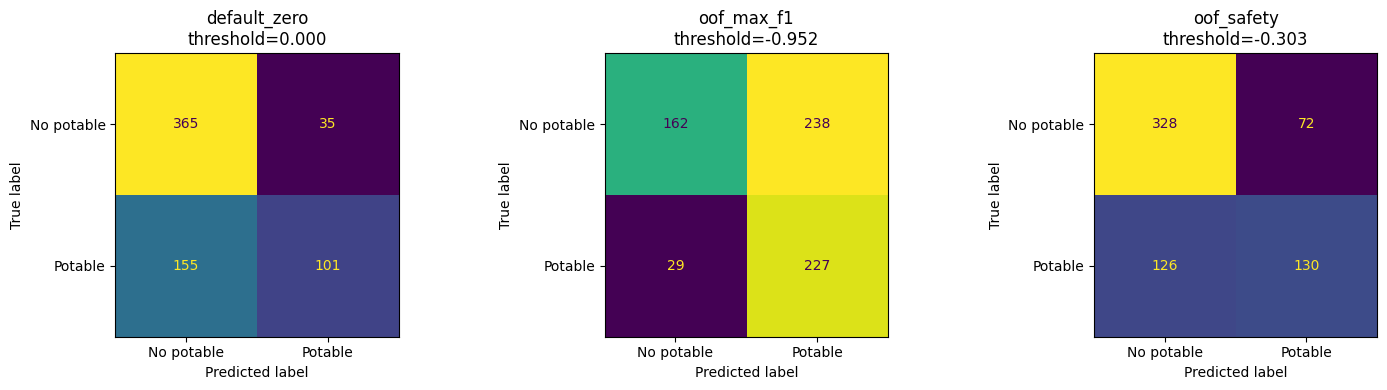

default_zero | threshold = 0.0
                precision    recall  f1-score   support

No potable (0)     0.7019    0.9125    0.7935       400
   Potable (1)     0.7426    0.3945    0.5153       256

      accuracy                         0.7104       656
     macro avg     0.7223    0.6535    0.6544       656
  weighted avg     0.7178    0.7104    0.6849       656

oof_max_f1 | threshold = -0.951651
                precision    recall  f1-score   support

No potable (0)     0.8482    0.4050    0.5482       400
   Potable (1)     0.4882    0.8867    0.6297       256

      accuracy                         0.5930       656
     macro avg     0.6682    0.6459    0.5890       656
  weighted avg     0.7077    0.5930    0.5800       656

oof_safety | threshold = -0.303264
                precision    recall  f1-score   support

No potable (0)     0.7225    0.8200    0.7681       400
   Potable (1)     0.6436    0.5078    0.5677       256

      accuracy                         0.6982      

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (policy, threshold) in zip(axes, threshold_policies.items()):
    pred = (reference_scores >= threshold).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        display_labels=['No potable', 'Potable'],
        colorbar=False,
        ax=ax,
    )
    ax.set_title(f'{policy}\nthreshold={threshold:.3f}')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'v3_reference_confusion_matrices.png', dpi=180, bbox_inches='tight')
plt.show()

for policy, threshold in threshold_policies.items():
    print('=' * 80)
    print(policy, '| threshold =', round(threshold, 6))
    print(classification_report(
        y_test,
        (reference_scores >= threshold).astype(int),
        target_names=['No potable (0)', 'Potable (1)'],
        digits=4,
        zero_division=0,
    ))


## 12. Auditoría de características y del remuestreo seleccionado


In [16]:
def selected_feature_names(model: Pipeline) -> list[str]:
    names = model.named_steps['feature_engineer'].get_feature_names_out(FEATURES)
    names = model.named_steps['imputer'].get_feature_names_out(names)
    names = model.named_steps['winsorizer'].get_feature_names_out(names)
    names = model.named_steps['local_geometry'].get_feature_names_out(names)
    return list(map(str, names))

model_feature_names = selected_feature_names(final_model)
print('Número de dimensiones finales:', len(model_feature_names))
print(model_feature_names)

X_stage = final_model.named_steps['feature_engineer'].transform(X_train)
X_stage = final_model.named_steps['imputer'].transform(X_stage)
X_stage = final_model.named_steps['winsorizer'].transform(X_stage)
X_stage = final_model.named_steps['scaler'].transform(X_stage)
X_stage = final_model.named_steps['local_geometry'].transform(X_stage)
X_resampled, y_resampled = final_model.named_steps['sampler'].fit_resample(X_stage, y_train)

balance_audit = {
    'before': dict(Counter(map(int, y_train))),
    'after': dict(Counter(map(int, y_resampled))),
    'reference_holdout': dict(Counter(map(int, y_test))),
    'input_dimensions': len(FEATURES),
    'model_dimensions': len(model_feature_names),
}
print(json.dumps(balance_audit, indent=2))

pd.Series(model_feature_names, name='feature_name').to_csv(
    ARTIFACT_DIR / 'v3_selected_feature_names.csv', index=False
)


Número de dimensiones finales: 11
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'local_mean_neighbor_distance', 'isolation_anomaly_score']
{
  "before": {
    "0": 1598,
    "1": 1022
  },
  "after": {
    "0": 1383,
    "1": 1022
  },
  "reference_holdout": {
    "1": 256,
    "0": 400
  },
  "input_dimensions": 9,
  "model_dimensions": 11
}


# Rama reducida: SVM clásica entrenada con 64 muestras

## 13. Selección inicial de 64 muestras desde el pool de entrenamiento

Esta V3 crea una primera versión funcional mediante muestreo estratificado fijo:

- 32 no potables y 32 potables;
- tomadas exclusivamente de `X_train`;
- sin SMOTE ni datos sintéticos;
- nueve variables originales;
- semilla fija y exportada;
- folds fijos exportados para reutilizarlos posteriormente.

La selección determinista por representatividad, clusters o cobertura de distribución se deja para una versión posterior, tal como se acordó.


In [17]:
small_idx_0 = y_train[y_train == 0].sample(
    n=SMALL64_N_PER_CLASS, random_state=SMALL64_SEED
).index
small_idx_1 = y_train[y_train == 1].sample(
    n=SMALL64_N_PER_CLASS, random_state=SMALL64_SEED
).index
small64_indices = np.r_[small_idx_0.to_numpy(), small_idx_1.to_numpy()]
np.random.default_rng(SMALL64_SEED).shuffle(small64_indices)

X_small64 = X_train.loc[small64_indices, FEATURES].copy()
y_small64 = y_train.loc[small64_indices].copy()

assert Counter(map(int, y_small64)) == Counter({0: 32, 1: 32})
assert set(small64_indices).isdisjoint(set(X_test.index))

small64_raw = X_small64.copy()
small64_raw.insert(0, 'source_index', small64_raw.index)
small64_raw[TARGET] = y_small64.to_numpy()
small64_raw.to_csv(ARTIFACT_DIR / 'svm64_training_raw.csv', index=False)

display(small64_raw.head())
print(Counter(map(int, y_small64)))

# Un único esquema fijo de cuatro folds quedará disponible para la futura QSVM.
small64_cv = StratifiedKFold(
    n_splits=SMALL64_FOLDS,
    shuffle=True,
    random_state=SMALL64_CV_SEED,
)
small64_splits = list(small64_cv.split(X_small64, y_small64))

fold_assignment = pd.DataFrame({
    'source_index': small64_indices,
    TARGET: y_small64.to_numpy(dtype=int),
    'validation_fold': -1,
})
for fold_number, (_, valid_pos) in enumerate(small64_splits):
    fold_assignment.loc[valid_pos, 'validation_fold'] = fold_number
assert (fold_assignment['validation_fold'] >= 0).all()
fold_assignment.to_csv(ARTIFACT_DIR / 'svm64_fixed_cv_folds.csv', index=False)
display(fold_assignment.sort_values('validation_fold').head(12))


,source_index,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
127,127,7.371085,207.716824,24913.837166,9.616330,362.300180,363.168538,11.542662,67.720704,4.412590,0
41,41,5.331940,194.874065,16658.876503,7.993830,316.675162,335.120398,10.180514,59.572714,4.434820,0
3183,3183,7.164478,213.002441,32751.928963,6.292148,NaN,490.933121,12.683767,58.252613,4.998203,1
1619,1619,6.962325,205.183020,35229.077002,5.088710,254.729932,360.058960,13.617560,NaN,4.526768,1
549,549,NaN,164.378433,15908.561870,11.208688,NaN,360.814296,17.239577,60.179119,4.380978,0


Counter({0: 32, 1: 32})


,source_index,Potability,validation_fold
1,41,0,0
2,3183,1,0
10,3103,0,0
8,378,1,0
12,3137,1,0
26,414,0,0
21,1533,1,0
23,1458,0,0
25,628,0,0
31,2664,0,0


## 14. Optimización del SVM-RBF de 64 muestras


In [18]:
def build_small64_pipeline(params: dict[str, Any]) -> Pipeline:
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('svc', SVC(
            kernel='rbf',
            C=float(params['C']),
            gamma=float(params['gamma']),
            probability=False,
            cache_size=1000,
            random_state=SMALL64_SEED,
        )),
    ])


def small64_objective(trial: optuna.Trial) -> float:
    params = {
        'C': trial.suggest_float('C', 1e-2, 1e2, log=True),
        'gamma': trial.suggest_float('gamma', 1e-3, 1.0, log=True),
    }
    aps, rocs = [], []
    for train_pos, valid_pos in small64_splits:
        model = build_small64_pipeline(params)
        model.fit(X_small64.iloc[train_pos], y_small64.iloc[train_pos])
        scores = model.decision_function(X_small64.iloc[valid_pos])
        truth = y_small64.iloc[valid_pos]
        aps.append(average_precision_score(truth, scores))
        rocs.append(roc_auc_score(truth, scores))
    mean_ap = float(np.mean(aps))
    mean_roc = float(np.mean(rocs))
    std_ap = float(np.std(aps))
    trial.set_user_attr('mean_average_precision', mean_ap)
    trial.set_user_attr('mean_roc_auc', mean_roc)
    trial.set_user_attr('std_average_precision', std_ap)
    return 0.70 * mean_ap + 0.30 * mean_roc - 0.10 * std_ap


small64_study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=SMALL64_SEED),
    study_name='water_potability_svm_64_v3',
)
small64_study.optimize(
    small64_objective,
    n_trials=CFG['small64_trials'],
    show_progress_bar=True,
)

small64_params = dict(small64_study.best_params)
print('Parámetros 64:', json.dumps(small64_params, indent=2))
small64_study.trials_dataframe().to_csv(
    ARTIFACT_DIR / 'svm64_optuna_trials.csv', index=False
)


[I 2026-07-21 21:50:33,514] A new study created in memory with name: water_potability_svm_64_v3


  0%|          | 0/45 [00:00<?, ?it/s]

[I 2026-07-21 21:50:33,608] Trial 0 finished with value: 0.6769894943295894 and parameters: {'C': 0.014843641541707532, 'gamma': 0.4052083675363218}. Best is trial 0 with value: 0.6769894943295894.
[I 2026-07-21 21:50:33,686] Trial 1 finished with value: 0.6673084849982647 and parameters: {'C': 29.05059959549512, 'gamma': 0.5146849395723732}. Best is trial 0 with value: 0.6769894943295894.
[I 2026-07-21 21:50:33,763] Trial 2 finished with value: 0.42690264663278216 and parameters: {'C': 1.3856024160824512, 'gamma': 0.0033444582912761788}. Best is trial 0 with value: 0.6769894943295894.
[I 2026-07-21 21:50:33,828] Trial 3 finished with value: 0.43736023816723196 and parameters: {'C': 0.011417146705021574, 'gamma': 0.0014822594767412618}. Best is trial 0 with value: 0.6769894943295894.
[I 2026-07-21 21:50:33,908] Trial 4 finished with value: 0.4662500629043729 and parameters: {'C': 10.115475427115173, 'gamma': 0.002068078350898673}. Best is trial 0 with value: 0.6769894943295894.
[I 2026

## 15. Estabilidad interna y evaluación del SVM entrenado con 64 muestras


In [19]:
small64_repeat_rows = []
for repeat in range(CFG['small64_repeats']):
    cv = StratifiedKFold(
        n_splits=SMALL64_FOLDS,
        shuffle=True,
        random_state=SMALL64_CV_SEED + repeat,
    )
    scores = cross_val_predict(
        build_small64_pipeline(small64_params),
        X_small64,
        y_small64,
        cv=cv,
        method='decision_function',
        n_jobs=N_JOBS,
    )
    maxf1, _ = optimize_threshold(y_small64, scores, min_specificity=None)
    safety, _ = optimize_threshold(
        y_small64,
        scores,
        min_specificity=MIN_SAFETY_SPECIFICITY,
    )
    small64_repeat_rows.append({
        'repeat': repeat,
        'average_precision': average_precision_score(y_small64, scores),
        'roc_auc': roc_auc_score(y_small64, scores),
        **{f'maxf1_{k}': v for k, v in maxf1.items()},
        **{f'safety_{k}': v for k, v in safety.items()},
    })

small64_stability = pd.DataFrame(small64_repeat_rows)
small64_stability.to_csv(ARTIFACT_DIR / 'svm64_cv_stability.csv', index=False)
display(small64_stability.round(4))

display(pd.DataFrame({
    'metric': [
        'average_precision', 'roc_auc', 'maxf1_f1', 'maxf1_specificity',
        'safety_f1', 'safety_specificity',
    ],
    'mean': [
        small64_stability['average_precision'].mean(),
        small64_stability['roc_auc'].mean(),
        small64_stability['maxf1_f1'].mean(),
        small64_stability['maxf1_specificity'].mean(),
        small64_stability['safety_f1'].mean(),
        small64_stability['safety_specificity'].mean(),
    ],
    'std': [
        small64_stability['average_precision'].std(),
        small64_stability['roc_auc'].std(),
        small64_stability['maxf1_f1'].std(),
        small64_stability['maxf1_specificity'].std(),
        small64_stability['safety_f1'].std(),
        small64_stability['safety_specificity'].std(),
    ],
}).round(4))

small64_maxf1_threshold = float(small64_stability['maxf1_threshold'].median())
small64_safety_threshold = float(small64_stability['safety_threshold'].median())

small64_model = build_small64_pipeline(small64_params)
small64_model.fit(X_small64, y_small64)
small64_reference_scores = small64_model.decision_function(X_test)

small64_rows = []
for policy, threshold in {
    'default_zero': 0.0,
    'oof_max_f1': small64_maxf1_threshold,
    'oof_safety': small64_safety_threshold,
}.items():
    metrics = classification_metrics(y_test, small64_reference_scores, threshold)
    metrics.update({
        'policy': policy,
        'average_precision': average_precision_score(y_test, small64_reference_scores),
        'roc_auc': roc_auc_score(y_test, small64_reference_scores),
    })
    small64_rows.append(metrics)

small64_reference_metrics = pd.DataFrame(small64_rows).set_index('policy')
small64_reference_metrics.to_csv(
    ARTIFACT_DIR / 'svm64_reference_holdout_metrics.csv'
)
display(small64_reference_metrics.round(4))


,repeat,average_precision,roc_auc,maxf1_threshold,maxf1_accuracy,maxf1_precision,maxf1_recall,maxf1_f1,maxf1_specificity,maxf1_false_positive_rate,...,safety_recall,safety_f1,safety_specificity,safety_false_positive_rate,safety_balanced_accuracy,safety_mcc,safety_tn,safety_fp,safety_fn,safety_tp
0,0,0.6293,0.6035,-0.0088,0.5625,0.5333,1.0000,0.6957,0.1250,0.8750,...,0.3438,0.4400,0.7812,0.2188,0.5625,0.1390,25.0,7.0,21.0,11.0
1,1,0.6561,0.6416,0.0006,0.6250,0.5769,0.9375,0.7143,0.3125,0.6875,...,0.3750,0.4615,0.7500,0.2500,0.5625,0.1348,24.0,8.0,20.0,12.0
2,2,0.6762,0.6641,0.0024,0.6250,0.5741,0.9688,0.7209,0.2812,0.7188,...,0.4688,0.5455,0.7500,0.2500,0.6094,0.2280,24.0,8.0,17.0,15.0
3,3,0.6205,0.6719,0.0030,0.7031,0.6512,0.8750,0.7467,0.5312,0.4688,...,0.3438,0.4314,0.7500,0.2500,0.5469,0.1026,24.0,8.0,21.0,11.0
4,4,0.6270,0.6494,0.0006,0.6094,0.5636,0.9688,0.7126,0.2500,0.7500,...,0.4062,0.4906,0.7500,0.2500,0.5781,0.1664,24.0,8.0,19.0,13.0
5,5,0.6068,0.6211,-0.0014,0.5938,0.5536,0.9688,0.7045,0.2188,0.7812,...,0.4062,0.4906,0.7500,0.2500,0.5781,0.1664,24.0,8.0,19.0,13.0
6,6,0.6625,0.6484,0.0023,0.6250,0.5800,0.9062,0.7073,0.3438,0.6562,...,0.4062,0.5000,0.7812,0.2188,0.5938,0.2023,25.0,7.0,19.0,13.0
7,7,0.5876,0.5986,-0.0014,0.6250,0.5714,1.0000,0.7273,0.2500,0.7500,...,0.2812,0.3673,0.7500,0.2500,0.5156,0.0354,24.0,8.0,23.0,9.0
8,8,0.6777,0.6533,0.0041,0.6250,0.5769,0.9375,0.7143,0.3125,0.6875,...,0.4375,0.5385,0.8125,0.1875,0.6250,0.2697,26.0,6.0,18.0,14.0
9,9,0.5635,0.5840,0.0006,0.5781,0.5455,0.9375,0.6897,0.2188,0.7812,...,0.3438,0.4314,0.7500,0.2500,0.5469,0.1026,24.0,8.0,21.0,11.0


,metric,mean,std
0,average_precision,0.6307,0.0380
1,roc_auc,0.6336,0.0299
2,maxf1_f1,0.7133,0.0162
3,maxf1_specificity,0.2844,0.1067
4,safety_f1,0.4697,0.0544
5,safety_specificity,0.7625,0.0219


,threshold,accuracy,precision,recall,f1,specificity,false_positive_rate,balanced_accuracy,mcc,tn,fp,fn,tp,average_precision,roc_auc
policy,,,,,,,,,,,,,,,
default_zero,0.0000,0.4101,0.3949,0.9609,0.5597,0.0575,0.9425,0.5092,0.0411,23,377,10,246,0.386,0.5144
oof_max_f1,0.0006,0.4101,0.3942,0.9531,0.5577,0.0625,0.9375,0.5078,0.0330,25,375,12,244,0.386,0.5144
oof_safety,0.0077,0.4939,0.4177,0.7539,0.5376,0.3275,0.6725,0.5407,0.0870,131,269,63,193,0.386,0.5144


## 16. Exportación completa de la rama de 64 muestras


In [20]:
# El preprocesador se ajusta únicamente con las 64 muestras.
small64_imputer = small64_model.named_steps['imputer']
small64_scaler = small64_model.named_steps['scaler']
X_small64_9d = small64_scaler.transform(small64_imputer.transform(X_small64))

small64_scaled = pd.DataFrame(X_small64_9d, columns=FEATURES)
small64_scaled.insert(0, 'source_index', small64_indices)
small64_scaled[TARGET] = y_small64.to_numpy(dtype=int)
small64_scaled.to_csv(ARTIFACT_DIR / 'svm64_training_strict_9d.csv', index=False)

np.savez_compressed(
    ARTIFACT_DIR / 'svm64_training_dataset.npz',
    X=X_small64_9d,
    y=y_small64.to_numpy(dtype=int),
    source_indices=small64_indices,
    feature_names=np.asarray(FEATURES, dtype=object),
)

joblib.dump(small64_model, ARTIFACT_DIR / 'svm64_rbf_pipeline.joblib')
joblib.dump(
    {
        'imputer': small64_imputer,
        'scaler': small64_scaler,
        'features': FEATURES,
    },
    ARTIFACT_DIR / 'svm64_strict_9d_preprocessor.joblib',
)

small64_manifest = {
    'selection_method': 'fixed_stratified_random_from_training_pool',
    'selection_seed': SMALL64_SEED,
    'cv_seed': SMALL64_CV_SEED,
    'n_samples': len(X_small64),
    'class_counts': dict(Counter(map(int, y_small64))),
    'feature_order': FEATURES,
    'best_params': small64_params,
    'median_max_f1_threshold': small64_maxf1_threshold,
    'median_safety_threshold': small64_safety_threshold,
    'minimum_safety_specificity': MIN_SAFETY_SPECIFICITY,
    'source_is_training_pool_only': True,
    'advanced_representative_selection_completed': False,
    'qsvm_completed': False,
}
with open(ARTIFACT_DIR / 'svm64_manifest.json', 'w', encoding='utf-8') as f:
    json.dump(small64_manifest, f, indent=2, ensure_ascii=False, default=str)


## 17. Manifiesto general de V3


In [21]:
manifest = {
    'dataset_path': str(DATA_PATH),
    'dataset_shape': list(df.shape),
    'feature_order': FEATURES,
    'train_size': len(X_train),
    'reference_holdout_size': len(X_test),
    'reference_holdout_seed': AUDIT_TEST_SEED,
    'selected_candidate': selected_candidate,
    'selected_params': selected_params,
    'selected_model_dimensions': len(model_feature_names),
    'threshold_policies': threshold_policies,
    'minimum_safety_specificity': MIN_SAFETY_SPECIFICITY,
    'small64': small64_manifest,
    'versions': {
        'python': platform.python_version(),
        'scikit_learn': sklearn.__version__,
        'imbalanced_learn': imblearn.__version__,
        'optuna': optuna.__version__,
        'numpy': np.__version__,
        'pandas': pd.__version__,
    },
}
with open(ARTIFACT_DIR / 'v3_manifest.json', 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False, default=str)

print('Artefactos V3:')
for item in sorted(ARTIFACT_DIR.iterdir()):
    print('-', item.name)


Artefactos V3:
- reference_holdout_v2_locked.csv
- svm64_cv_stability.csv
- svm64_fixed_cv_folds.csv
- svm64_manifest.json
- svm64_optuna_trials.csv
- svm64_rbf_pipeline.joblib
- svm64_reference_holdout_metrics.csv
- svm64_strict_9d_preprocessor.joblib
- svm64_training_dataset.npz
- svm64_training_raw.csv
- svm64_training_strict_9d.csv
- svm_rbf_v3_selected_pipeline.pkl
- v3_candidate_stability_repeats.csv
- v3_candidate_summary.csv
- v3_manifest.json
- v3_optuna_trials.csv
- v3_reference_confusion_matrices.png
- v3_reference_holdout_metrics.csv
- v3_selected_configuration.json
- v3_selected_feature_names.csv
- v3_threshold_nested_audit.csv


## 18. Reglas de interpretación

### Modelo completo

- Comparar V3 contra `v2_reference` mediante estabilidad CV, no únicamente por un valor del holdout.
- Reportar `average_precision`, ROC-AUC, F1, especificidad, MCC y matrices de confusión.
- Para un caso de seguridad, la política `oof_safety` es la recomendada.
- No eliminar manualmente observaciones mirando su etiqueta o el resultado del test.

### Modelo clásico de 64 muestras

- Fue entrenado con 64 observaciones reales del pool de entrenamiento.
- No contiene muestras del holdout ni datos sintéticos.
- Sus folds fijos se exportaron para reutilización futura.
- La selección por representatividad y el QSVM se implementarán después.
- Para una comparación clásica–cuántica posterior, ambos modelos deberán utilizar exactamente las mismas 64 filas, las mismas nueve variables y los mismos folds.
